In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [50]:
import warnings
warnings.filterwarnings('ignore')

In [51]:
data = pd.read_csv('clustering.csv')

In [52]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [54]:
data = data.select_dtypes('number')

In [55]:
data.dropna(inplace=True)

In [56]:
from sklearn.cluster import KMeans

In [ ]:
# data = clustering_data.drop('Loan_ID',axis=1)
# data.shape

In [ ]:
# data.Gender.unique()

In [ ]:
# data.Gender=data.Gender.apply(lambda x: 1 if x=="Male" else 0)

In [ ]:
# data.Married.unique()

In [ ]:
# data.Married=data.Married.apply(lambda x: 1 if x=="Yes" else 0)

In [23]:
# data.Education.unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [24]:
# data.Education=data.Education.apply(lambda x: 1 if x=="Graduate" else 0)

In [25]:
# data.Self_Employed.unique()

array(['No', 'Yes'], dtype=object)

In [26]:
# data.Self_Employed=data.Self_Employed.apply(lambda x: 1 if x=="Yes" else 0)

In [27]:
# data.Property_Area.unique()

array(['Rural', 'Urban', 'Semiurban'], dtype=object)

In [28]:
# data.Property_Area = data.Property_Area.apply(lambda x: 1 if x=='Rural' else 0)

In [29]:
# data.Loan_Status.unique()

array(['N', 'Y'], dtype=object)

In [30]:
# data.Loan_Status = data.Loan_Status.apply(lambda x: 1 if x=='Yes' else 0)

In [33]:
# data.Dependents.unique()

array(['1', '0', '2', '3+'], dtype=object)

In [34]:
# data.Dependents = data.Dependents.apply(lambda x: 0 if x=="0" else 1 if x=="1" else 2 if x=="2" else 3)

# elbow method

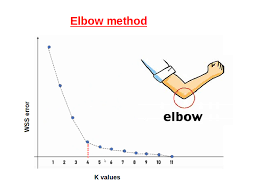

Text(0, 0.5, 'Inertia')

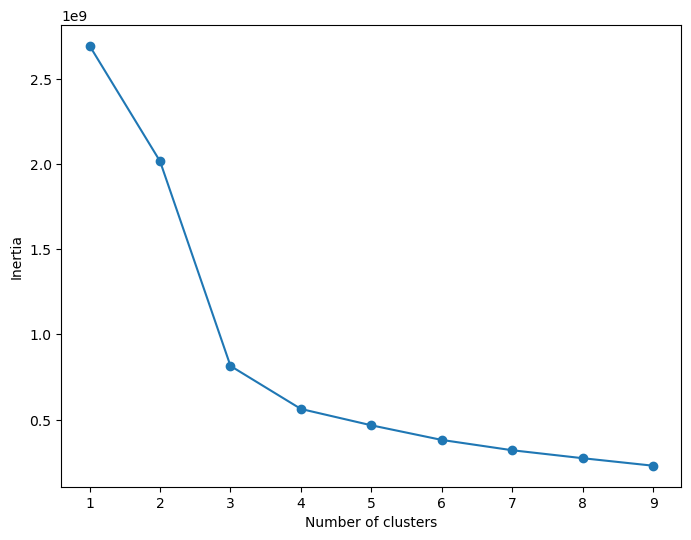

In [57]:
wcss = [] # within cluster sum of squared 
for cluster in range(1,10):
    kmeans = KMeans(n_clusters = cluster, init='k-means++')
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)


frame = pd.DataFrame({'Cluster':range(1,10), 'wcss':wcss})
plt.figure(figsize=(8,6))
plt.plot(frame['Cluster'], frame['wcss'], marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

In [68]:
data.corr()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Cluster
ApplicantIncome,1.000000,-0.255239,0.256709,-0.088938,0.022648,0.147943
CoapplicantIncome,-0.255239,1.000000,0.124824,0.003302,0.011843,-0.351700
LoanAmount,0.256709,0.124824,1.000000,0.149059,-0.053086,-0.343357
Loan_Amount_Term,-0.088938,0.003302,0.149059,1.000000,-0.013452,-0.027748
Credit_History,0.022648,0.011843,-0.053086,-0.013452,1.000000,0.061108
Cluster,0.147943,-0.351700,-0.343357,-0.027748,0.061108,1.000000


In [58]:
kmeans = KMeans(n_clusters = 4)
kmeans.fit(data)
pred = kmeans.predict(data)
pred

array([3, 3, 0, 1, 0, 3, 0, 0, 0, 1, 3, 1, 1, 0, 0, 0, 3, 3, 0, 3, 3, 0,
       0, 0, 3, 0, 0, 1, 1, 0, 0, 0, 3, 3, 3, 0, 0, 0, 0, 0, 3, 3, 0, 1,
       3, 0, 3, 3, 0, 3, 3, 0, 0, 0, 0, 3, 3, 0, 0, 3, 0, 0, 3, 1, 3, 1,
       0, 1, 3, 0, 3, 0, 3, 3, 1, 3, 0, 3, 0, 0, 0, 1, 1, 3, 3, 0, 0, 0,
       1, 3, 0, 3, 0, 3, 3, 0, 0, 3, 0, 3, 3, 3, 1, 3, 3, 0, 3, 3, 3, 3,
       0, 3, 3, 3, 1, 0, 3, 0, 0, 1, 3, 0, 0, 1, 3, 0, 3, 0, 3, 3, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 3, 0, 1, 1, 0, 1, 1, 3, 3, 0, 3, 0, 0, 3, 0,
       0, 3, 0, 0, 0, 0, 0, 3, 0, 3, 0, 1, 3, 3, 0, 0, 0, 1, 0, 0, 0, 0,
       3, 0, 3, 0, 3, 0, 3, 1, 0, 3, 0, 3, 3, 3, 3, 3, 0, 0, 0, 1, 3, 3,
       3, 0, 3, 0, 1, 1, 3, 0, 0, 3, 1, 3, 1, 0, 1, 3, 3, 0, 0, 1, 0, 0,
       3, 0, 0, 0, 3, 3, 2, 3, 3, 0, 3, 3, 0, 3, 0, 0, 1, 0, 0, 3, 1, 3,
       3, 1, 1, 0, 3, 0, 1, 0, 3, 3, 0, 0, 0, 0, 0, 1, 3, 3, 3, 1, 1, 3,
       1, 0, 0, 0, 0, 3, 0, 3, 0, 0, 3, 3, 3, 0, 3, 0, 3, 0, 3, 0, 3, 3,
       0, 0, 0, 0, 0, 3, 0, 3, 1, 3, 0, 1, 3, 3, 0,

In [60]:
data['Cluster'] = pred

In [62]:
data[data.Cluster==0]

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Cluster
2,2583,2358.0,120.0,360.0,1.0,0
4,2333,1516.0,95.0,360.0,1.0,0
6,2500,1840.0,109.0,360.0,1.0,0
7,1853,2840.0,114.0,360.0,1.0,0
8,1299,1086.0,17.0,120.0,1.0,0
...,...,...,...,...,...,...
367,2787,1917.0,146.0,360.0,0.0,0
368,2297,1522.0,104.0,360.0,1.0,0
372,3000,3416.0,56.0,180.0,1.0,0
373,3859,3300.0,142.0,180.0,1.0,0


In [63]:
data[data.Cluster==1]

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Cluster
3,6000,0.0,141.0,360.0,1.0,1
9,4950,0.0,125.0,360.0,1.0,1
12,4887,0.0,133.0,360.0,1.0,1
14,7660,0.0,104.0,360.0,0.0,1
33,5649,0.0,44.0,360.0,1.0,1
34,5821,0.0,144.0,360.0,1.0,1
49,7100,0.0,125.0,60.0,1.0,1
72,7333,0.0,120.0,360.0,1.0,1
74,5316,0.0,136.0,360.0,1.0,1
76,5050,0.0,118.0,360.0,1.0,1


In [65]:
data[data.Cluster==3]

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Cluster
0,4583,1508.0,128.0,360.0,1.0,3
1,3000,0.0,66.0,360.0,1.0,3
5,3200,700.0,70.0,360.0,1.0,3
11,3510,0.0,76.0,360.0,0.0,3
18,4226,1040.0,110.0,360.0,1.0,3
...,...,...,...,...,...,...
374,3833,0.0,110.0,360.0,1.0,3
375,2987,0.0,88.0,360.0,0.0,3
378,2900,0.0,71.0,360.0,1.0,3
379,4106,0.0,40.0,180.0,1.0,3


# Silhoute Score

In [66]:
from sklearn.metrics import silhouette_score
score = silhouette_score(data, pred)
print(f"Silhouette Score: {score}")

In [67]:
score = silhouette_score(data, pred)
print(f"Silhouette Score: {score}")

Silhouette Score: 0.4434568566784866
